# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import mlflow
import mlflow.sklearn
import urllib
from sqlalchemy import create_engine
import pyodbc
import time

1. Load Data

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\telcom_data (2).xlsx - Sheet1.csv")

In [3]:
df.columns = df.columns.str.strip()

 Treat Missing Values & Outliers with Mean

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

Handset Analysis

In [5]:
print("--- Top 10 Handsets ---")
print(df['Handset Type'].value_counts().head(10))

--- Top 10 Handsets ---
Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


In [6]:
print("\n--- Top 3 Handset Manufacturers ---")
top_3_mfr = df['Handset Manufacturer'].value_counts().head(3)
print(top_3_mfr)


--- Top 3 Handset Manufacturers ---
Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64


In [7]:
print("\n--- Top 5 Handsets per Top 3 Manufacturer ---")
for mfr in top_3_mfr.index:
    print(f"\nManufacturer: {mfr}")
    print(df[df['Handset Manufacturer'] == mfr]['Handset Type'].value_counts().head(5))


--- Top 5 Handsets per Top 3 Manufacturer ---

Manufacturer: Apple
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Manufacturer: Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Manufacturer: Huawei
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


Application Data Total Calculation

In [8]:
apps = ['Social Media', 'Google', 'Email', 'YouTube', 'Netflix', 'Gaming', 'Other']
for app in apps:
    df[f'{app}_Total'] = df.get(f'{app} DL (Bytes)', 0) + df.get(f'{app} UL (Bytes)', 0)

In [9]:
print("\n✅ Task 1: Basic Analysis & Cleaning Complete!")


✅ Task 1: Basic Analysis & Cleaning Complete!


# Advanced EDA (Deciles, PCA, Plots)

User Aggregation

In [10]:
user_overview = df.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count', 'Dur. (ms)': 'sum', 
    'Total DL (Bytes)': 'sum', 'Total UL (Bytes)': 'sum',
    **{f'{app}_Total': 'sum' for app in apps}
}).rename(columns={'Bearer Id': 'sessions'})
user_overview['Total_Traffic'] = user_overview['Total DL (Bytes)'] + user_overview['Total UL (Bytes)']

Dispersion Parameters

In [11]:
print("\n--- Dispersion Parameters ---")
display(user_overview.agg(['mean', 'median', 'var', 'skew']).transpose())


--- Dispersion Parameters ---


,mean,median,var,skew
sessions,1.403755e+00,1.0,1.125624e+01,299.048050
Dur. (ms),1.468447e+05,102741.0,8.378975e+10,151.936059
Total DL (Bytes),6.382078e+08,570371256.0,2.432981e+18,284.431635
Total UL (Bytes),5.772408e+07,46794345.0,1.964459e+16,295.720248
Social Media_Total,2.566415e+06,2303811.0,4.000603e+13,283.356760
Google_Total,1.095953e+07,9586186.0,6.919751e+14,287.450387
Email_Total,3.171225e+06,2799854.0,5.869612e+13,286.568149
YouTube_Total,0.000000e+00,0.0,0.000000e+00,0.000000
Netflix_Total,3.176501e+07,26719548.0,5.943821e+15,290.273460
Gaming_Total,6.040820e+08,542350112.0,2.189520e+18,282.826467


Decile Analysis

In [12]:
user_overview['decile'] = pd.qcut(user_overview['Dur. (ms)'], 10, labels=False, duplicates='drop')
print("\n--- Total Data per Decile Class ---")
print(user_overview.groupby('decile')['Total_Traffic'].sum())


--- Total Data per Decile Class ---
decile
0    5.439277e+12
1    6.109410e+12
2    6.536402e+12
3    6.034241e+12
4    5.144182e+12
5    6.425801e+12
6    6.152478e+12
7    7.822234e+12
8    9.306258e+12
9    1.539491e+13
Name: Total_Traffic, dtype: float64


Graphical Univariate (Histogram) & Bivariate (Scatter)

Text(0.5, 1.0, 'Univariate: Total Traffic Distribution')

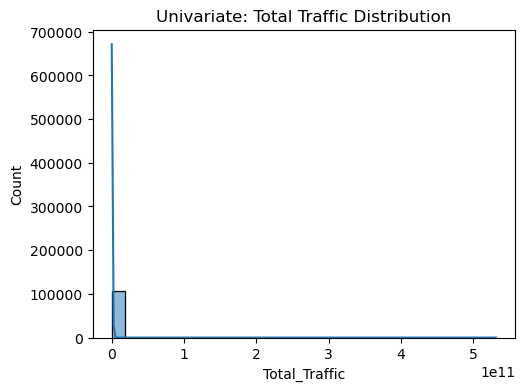

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(user_overview['Total_Traffic'], bins=30, kde=True)
plt.title('Univariate: Total Traffic Distribution')

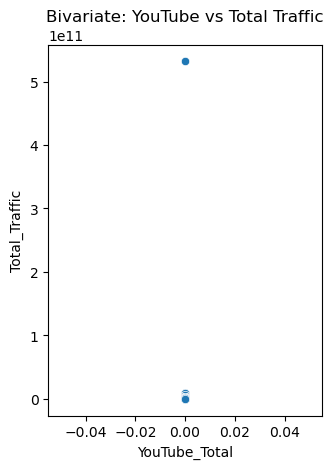

In [14]:
plt.subplot(1, 2, 2)
sns.scatterplot(x=user_overview['YouTube_Total'], y=user_overview['Total_Traffic'])
plt.title('Bivariate: YouTube vs Total Traffic')
plt.tight_layout()
plt.show()

PCA

In [15]:
scaler = StandardScaler()
app_cols = [f'{app}_Total' for app in apps]
pca = PCA(n_components=2).fit(scaler.fit_transform(user_overview[app_cols]))
print(f"PCA Variance Explained: {pca.explained_variance_ratio_}")

PCA Variance Explained: [0.97403856 0.00650811]


# User Engagement Analysis

In [16]:
print("--- Top 10 by Sessions --- \n", user_overview['sessions'].nlargest(10))

--- Top 10 by Sessions --- 
 MSISDN/Number
4.188282e+10    1066
3.362632e+10      18
3.361489e+10      17
3.362578e+10      17
3.365973e+10      16
3.367588e+10      15
3.376054e+10      15
3.366716e+10      13
3.360313e+10      12
3.360452e+10      12
Name: sessions, dtype: int64


Normalize & K-Means (k=3)

In [17]:
eng_metrics = ['sessions', 'Dur. (ms)', 'Total_Traffic']
eng_scaled = scaler.fit_transform(user_overview[eng_metrics])
kmeans_eng = KMeans(n_clusters=3, random_state=42).fit(eng_scaled)
user_overview['eng_cluster'] = kmeans_eng.labels_

Min, Max, Average & Total per Cluster (Non-Normalized)

In [18]:
print("\n--- Cluster Metrics (Min, Max, Avg, Total) ---")
display(user_overview.groupby('eng_cluster')[eng_metrics].agg(['min', 'max', 'mean', 'sum']))


--- Cluster Metrics (Min, Max, Avg, Total) ---


sessions                                Dur. (ms)                \
                 min   max         mean     sum           min           max   
eng_cluster                                                                   
0                  1     7     1.361920  144083  7.142000e+03  7.835760e+05   
1               1066  1066  1066.000000    1066  7.255100e+07  7.255100e+07   
2                  1    18     4.568738    4852  5.677860e+05  1.855375e+07   

                                        Total_Traffic                \
                     mean           sum           min           max   
eng_cluster                                                           
0            1.347519e+05  1.425595e+10  3.324901e+07  4.478299e+09   
1            7.255100e+07  7.255100e+07  5.317447e+11  5.317447e+11   
2            1.283324e+06  1.362890e+09  9.705338e+07  8.846226e+09   

                                         
                     mean           sum  
eng_cluster                              
0            6.750952e+08  7.142102e+13  
1            5.317447e+11  5.317447e+11  
2            2.271590e+09  2.412429e+12

Top 10 Users per Application

In [19]:
print("\n--- Top 10 Users for YouTube ---")
print(user_overview['YouTube_Total'].nlargest(10)) # Repeat for other apps in PPT


--- Top 10 Users for YouTube ---
MSISDN/Number
3.360100e+10    0
3.360100e+10    0
3.360100e+10    0
3.360101e+10    0
3.360101e+10    0
3.360101e+10    0
3.360101e+10    0
3.360101e+10    0
3.360101e+10    0
3.360102e+10    0
Name: YouTube_Total, dtype: int64


Plot Top 3 Most Used Applications

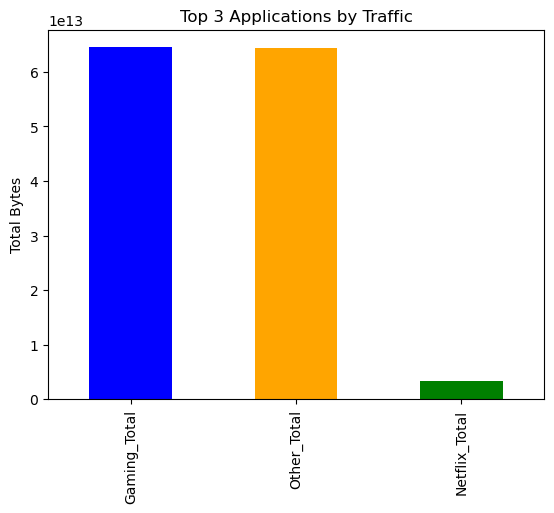

In [20]:
top_3_apps = user_overview[app_cols].sum().nlargest(3)
top_3_apps.plot(kind='bar', color=['blue', 'orange', 'green'], title='Top 3 Applications by Traffic')
plt.ylabel('Total Bytes')
plt.show()

# Experience Analytics

Aggregate Network Metrics

In [21]:
exp_cols = ['TCP DL Retrans. Vol (Bytes)', 'Avg RTT DL (ms)', 'Avg Bearer TP DL (kbps)']
user_exp = df.groupby('MSISDN/Number')[exp_cols].mean().fillna(df[exp_cols].mean())

Top 10, Bottom 10, Most Frequent (Example for TCP)

In [22]:
print("--- TCP Top 10 --- \n", df['TCP DL Retrans. Vol (Bytes)'].nlargest(10))
print("\n--- TCP Bottom 10 --- \n", df['TCP DL Retrans. Vol (Bytes)'].nsmallest(10))
print("\n--- TCP Most Frequent --- \n", df['TCP DL Retrans. Vol (Bytes)'].value_counts().head(5))

--- TCP Top 10 --- 
 77950     4.294426e+09
135677    4.291380e+09
34636     4.289877e+09
140797    4.289488e+09
3741      4.288060e+09
119667    4.275259e+09
39608     4.268432e+09
76971     4.259997e+09
59011     4.256650e+09
41182     4.254644e+09
Name: TCP DL Retrans. Vol (Bytes), dtype: float64

--- TCP Bottom 10 --- 
 59708     2.0
125088    2.0
2818      4.0
39582     4.0
52480     4.0
60366     4.0
60417     4.0
75082     4.0
100305    4.0
143429    4.0
Name: TCP DL Retrans. Vol (Bytes), dtype: float64

--- TCP Most Frequent --- 
 TCP DL Retrans. Vol (Bytes)
2.080991e+07    88146
1.330000e+03      433
2.660000e+03      219
3.800000e+01      200
9.200000e+01      192
Name: count, dtype: int64


Distribution of Throughput & TCP per Handset Type

In [23]:
top_handsets = df['Handset Type'].value_counts().head(10).index
handset_data = df[df['Handset Type'].isin(top_handsets)]

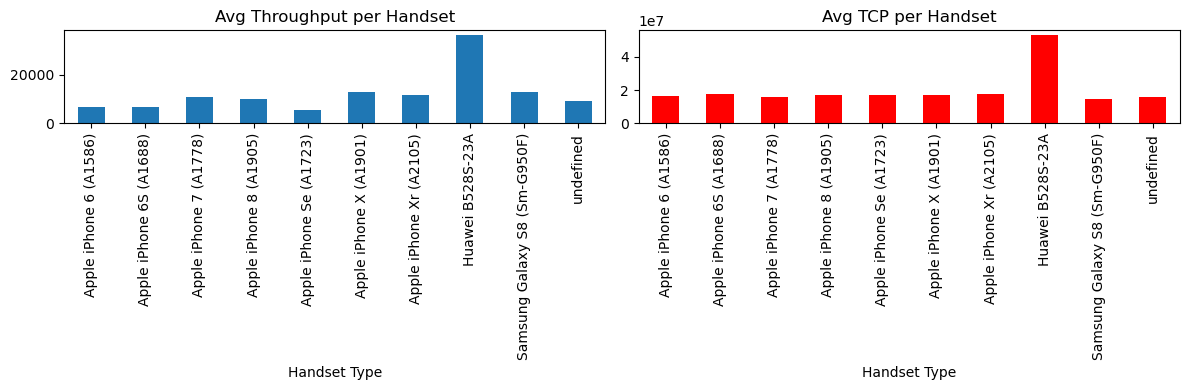

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
handset_data.groupby('Handset Type')['Avg Bearer TP DL (kbps)'].mean().plot(kind='bar', title='Avg Throughput per Handset')
plt.subplot(1, 2, 2)
handset_data.groupby('Handset Type')['TCP DL Retrans. Vol (Bytes)'].mean().plot(kind='bar', color='red', title='Avg TCP per Handset')
plt.tight_layout()
plt.show()

K-Means (k=3) for Experience

In [25]:
exp_scaled = scaler.fit_transform(user_exp)
kmeans_exp = KMeans(n_clusters=3, random_state=42).fit(exp_scaled)
user_overview['exp_cluster'] = kmeans_exp.labels_

# Satisfaction, Regression & Export

Euclidean Distance Scores

In [26]:
center_eng = kmeans_eng.cluster_centers_[np.argmin(np.linalg.norm(kmeans_eng.cluster_centers_, axis=1))]
center_exp = kmeans_exp.cluster_centers_[np.argmax(kmeans_exp.cluster_centers_[:, 0])]

In [27]:
user_overview['engagement_score'] = np.linalg.norm(eng_scaled - center_eng, axis=1)
user_overview['experience_score'] = np.linalg.norm(exp_scaled - center_exp, axis=1)

Satisfaction Score & Top 10 Satisfied Customers

In [28]:
user_overview['satisfaction_score'] = (user_overview['engagement_score'] + user_overview['experience_score']) / 2
print("--- Top 10 Satisfied Customers --- \n", user_overview['satisfaction_score'].nlargest(10))

--- Top 10 Satisfied Customers --- 
 MSISDN/Number
4.188282e+10    266.893327
3.366232e+10     84.538457
3.368369e+10     48.817477
3.362578e+10     43.355793
3.366087e+10     30.323949
3.361489e+10     28.689130
3.376054e+10     27.455557
3.362632e+10     26.706471
3.366716e+10     26.453168
3.376094e+10     26.162617
Name: satisfaction_score, dtype: float64


Regression Model

In [29]:
X = user_overview[['engagement_score', 'experience_score']]
y = user_overview['satisfaction_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_model = LinearRegression().fit(X_train, y_train)
print(f"\nModel Accuracy (R2 Score): {r2_score(y_test, reg_model.predict(X_test)):.4f}")


Model Accuracy (R2 Score): 1.0000


 K-Means on Scores & Cluster Averages

In [30]:
user_overview['score_cluster'] = KMeans(n_clusters=2, random_state=42).fit_predict(user_overview[['engagement_score', 'experience_score']])
print("\n--- Avg Satisfaction & Experience per Cluster ---")
display(user_overview.groupby('score_cluster')[['satisfaction_score', 'experience_score']].mean())


--- Avg Satisfaction & Experience per Cluster ---


,satisfaction_score,experience_score
score_cluster,,
0,11.585959,22.734912
1,266.893327,22.707646


Export to Final CSV & MLflow Track

In [31]:
user_overview.to_csv("Final_Database_Export.csv")
print("\n✅ Saved Final Database Export!")


✅ Saved Final Database Export!


--- SQL Server Details ---

In [32]:


# 1. Connection Settings
server = "LAPTOP-NFDKAD4I\SQLEXPRESS"
database = 'telecom_db'
driver = '{SQL Server}'

# 2. Connection String
conn_str = f'DRIVER={driver};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # 3. Connect to SQL
    conn = pyodbc.connect(conn_str)
    cursor = conn.cursor()

    # 4. Create Table
    cursor.execute("IF OBJECT_ID('User_Satisfaction_Final', 'U') IS NOT NULL DROP TABLE User_Satisfaction_Final")
    cursor.execute("CREATE TABLE User_Satisfaction_Final (MSISDN_Number NVARCHAR(50), Engagement_Score FLOAT, Experience_Score FLOAT, Satisfaction_Score FLOAT)")

    # 5. Insert Data (Top 100)
    for index, row in user_overview.head(100).iterrows():
        cursor.execute("INSERT INTO User_Satisfaction_Final VALUES (?, ?, ?, ?)", str(index), float(row['engagement_score']), float(row['experience_score']), float(row['satisfaction_score']))

    conn.commit()
    cursor.close()
    conn.close()
    print("✅ Task 4.6 Successful! Table 'User_Satisfaction_Final")

except Exception as e:
    print(f"❌ Error: {str(e)}")

✅ Task 4.6 Successful! Table 'User_Satisfaction_Final


Experiment

In [33]:
import mlflow
import mlflow.sklearn
import time

# Experiment 
mlflow.set_experiment("Telecom_Satisfaction_Analysis")

with mlflow.start_run(run_name="Final_Model_Run"):
    # 1. Start Time 
    mlflow.log_param("model_type", "Linear Regression")
    mlflow.log_param("test_size", 0.2)
    
    # 3. Metrics  (Accuracy/Loss)
    accuracy = r2_score(y_test, reg_model.predict(X_test))
    mlflow.log_metric("R2_Score", accuracy)
    
    # 4. Model Save 
    mlflow.sklearn.log_model(reg_model, "satisfaction_model")
    
    # 5. Artifacts (CSV File) 
    
    mlflow.log_artifact("Final_Database_Export.csv")
    
    print("✅ MLflow Tracking Complete! Check Dashboard at http://localhost:5000")

2026/04/06 00:49:41 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/04/06 00:49:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

✅ MLflow Tracking Complete! Check Dashboard at http://localhost:5000


In [34]:
import mlflow
print("MLflow storage location:", mlflow.get_tracking_uri())

MLflow storage location: sqlite:///C:/Users/ASUS/mlflow.db


In [35]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("📱 TellCo User Satisfaction Dashboard")

try:
    df = pd.read_csv("Final_Database_Export.csv")
    
    st.write("### Data Preview", df.head())
    
    
    st.write("Columns in your file:", list(df.columns))

    
    available_cols = [col for col in ['Engagement_Score', 'Experience_Score', 'Satisfaction_Score'] if col in df.columns]
    
    if available_cols:
        st.bar_chart(df[available_cols].head(20))
        st.success("Dashboard Ready!")
    else:
        st.error("Wait! 'Engagement_Score' columns not found. Please check the column names above.")

except Exception as e:
    st.error(f"Error: {e}")

Overwriting app.py


In [37]:
import os
print(os.getcwd())

C:\Users\ASUS
